# Khám phá dữ liệu (EDA)Bộ dữ liệu là tập con của COCO 2017, giữ lại 5 lớp rau củ quả:apple, banana, broccoli, carrot, orange.Notebook này gồm hai phần:1. Thống kê và biểu đồ mô tả dữ liệu.2. Chạy thử ba mô hình ở trạng thái gốc (checkpoint COCO, chưa huấn luyện lại)   trên cùng ba tấm ảnh để xem chúng phát hiện được gì.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import CLASSES, CLASS_COLORS_RGB, COCO_ID_TO_CLASS, SPLITS
from src.data.coco_dataset import CocoRecords
from src.evaluation.figures import draw_boxes

# src.evaluation.figures dat backend "Agg" de chay duoc khi khong co man hinh.
# Dong duoi tra backend ve inline de hinh hien ra trong notebook.
%matplotlib inline

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

# Mau cua moi lop dung chung voi phan bao cao va ung dung web.
COLORS = {name: tuple(c / 255 for c in rgb) for name, rgb in CLASS_COLORS_RGB.items()}

records = {split: CocoRecords(split) for split in SPLITS}
print("Da nap:", {s: len(r) for s, r in records.items()})

Da nap: {'train': 5803, 'val': 1024, 'test': 310}


## 1. Số lượng ảnh và instanceMột "instance" là một hộp bao quanh một vật thể. Một ảnh có thể chứa nhiều instance.

In [2]:
rows = []
for split in SPLITS:
    anns = [a for r in records[split].records for a in r["annotations"]]
    n_img = len(records[split])
    rows.append({
        "split": split,
        "so anh": n_img,
        "so instance": len(anns),
        "instance/anh": round(len(anns) / n_img, 2),
        "anh khong co vat the": sum(1 for r in records[split].records if not r["annotations"]),
    })

overview = pd.DataFrame(rows)
overview.loc[len(overview)] = {
    "split": "tong",
    "so anh": overview["so anh"].sum(),
    "so instance": overview["so instance"].sum(),
    "instance/anh": round(overview["so instance"].sum() / overview["so anh"].sum(), 2),
    "anh khong co vat the": overview["anh khong co vat the"].sum(),
}
overview

,split,so anh,so instance,instance/anh,anh khong co vat the
0,train,5803,30902,5.33,0
1,val,1024,5390,5.26,0
2,test,310,1568,5.06,0
3,tong,7137,37860,5.30,0


Tập train và val được cắt ra từ COCO train2017. Tập test lấy từ COCO val2017,tức là một đợt thu thập khác, nên nó không chia sẻ phân phối với hai tập kia.

## 2. Số instance theo từng lớpBiểu đồ dưới cho biết mỗi lớp có bao nhiêu vật thể trong từng tập.

,train,val,test,tong,ty le %
apple,4963,813,236,6012,15.9
banana,7769,1426,370,9565,25.3
broccoli,6209,1052,312,7573,20.0
carrot,6628,1130,365,8123,21.5
orange,5333,969,285,6587,17.4


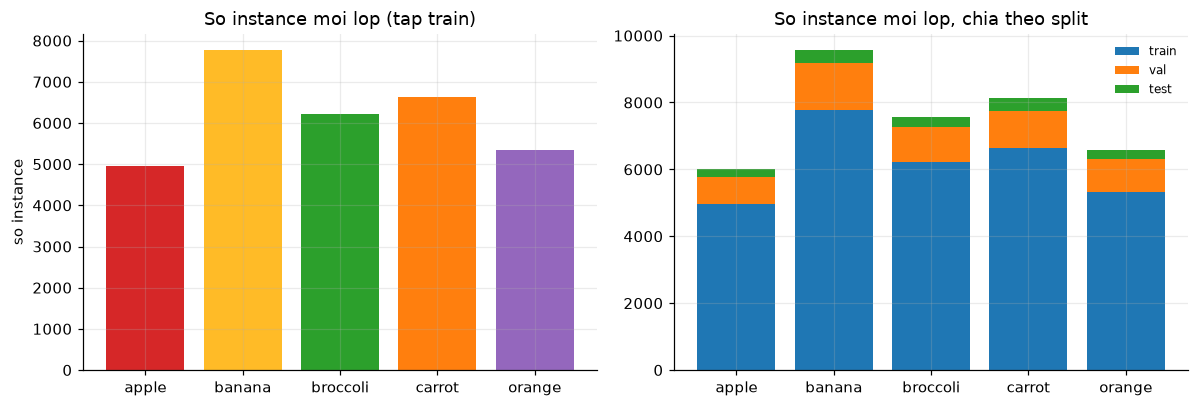

In [3]:
counts = {
    split: pd.Series(
        [COCO_ID_TO_CLASS[a["category_id"]]
         for r in records[split].records for a in r["annotations"]]
    ).value_counts().reindex(CLASSES, fill_value=0)
    for split in SPLITS
}
class_table = pd.DataFrame(counts)
class_table["tong"] = class_table.sum(axis=1)
class_table["ty le %"] = (100 * class_table["tong"] / class_table["tong"].sum()).round(1)
display(class_table)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].bar(CLASSES, class_table["train"], color=[COLORS[c] for c in CLASSES])
axes[0].set_title("So instance moi lop (tap train)")
axes[0].set_ylabel("so instance")

bottom = np.zeros(len(CLASSES))
for split in SPLITS:
    values = class_table[split].values
    axes[1].bar(CLASSES, values, bottom=bottom, label=split)
    bottom += values
axes[1].set_title("So instance moi lop, chia theo split")
axes[1].legend(frameon=False, fontsize=8)

fig.tight_layout()
plt.show()

Mức chênh lệch giữa lớp nhiều nhất và lớp ít nhất cho biết dữ liệu có mất cân bằng hay không.Nếu một lớp chiếm tỉ lệ quá nhỏ, mô hình thường nhận diện lớp đó kém hơn.

## 3. Số instance trên mỗi ảnhCho biết ảnh trong bộ dữ liệu thường chứa một vài vật thể hay chứa rất nhiều.

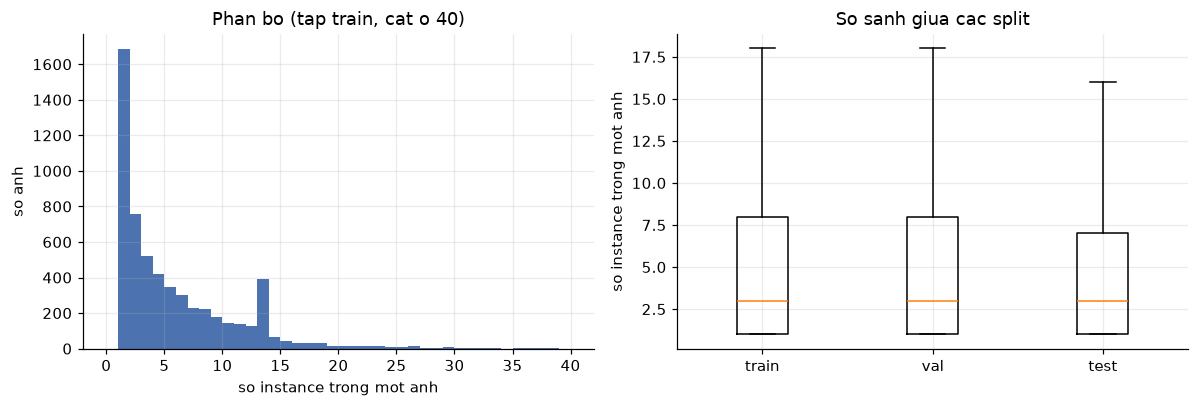

,train,val,test
trung binh,5.33,5.26,5.06
trung vi,3.00,3.00,3.00
lon nhat,38.00,34.00,27.00
phan vi 90%,13.00,13.00,13.00


In [4]:
per_image = {s: np.array([len(r["annotations"]) for r in records[s].records]) for s in SPLITS}

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].hist(per_image["train"], bins=range(0, 41), color="#4c72b0")
axes[0].set_xlabel("so instance trong mot anh")
axes[0].set_ylabel("so anh")
axes[0].set_title("Phan bo (tap train, cat o 40)")

axes[1].boxplot([per_image[s] for s in SPLITS], tick_labels=list(SPLITS), showfliers=False)
axes[1].set_ylabel("so instance trong mot anh")
axes[1].set_title("So sanh giua cac split")

fig.tight_layout()
plt.show()

stats = pd.DataFrame({
    s: {"trung binh": per_image[s].mean().round(2),
        "trung vi": float(np.median(per_image[s])),
        "lon nhat": int(per_image[s].max()),
        "phan vi 90%": float(np.percentile(per_image[s], 90))}
    for s in SPLITS
})
stats

## 4. Kích thước vật thể và kích thước ảnhCOCO chia vật thể thành ba nhóm theo diện tích hộp: nhỏ (dưới 32x32 pixel),trung bình (32x32 den 96x96) và lớn (trên 96x96). Cách chia này được dùng lạikhi tính mAP, nên biết tỉ lệ ba nhóm giúp giải thích kết quả của mô hình.

Ty le theo nhom kich thuoc COCO (tap train):
nho (<32x32)    26.4
trung binh      45.1
lon (>96x96)    28.5 



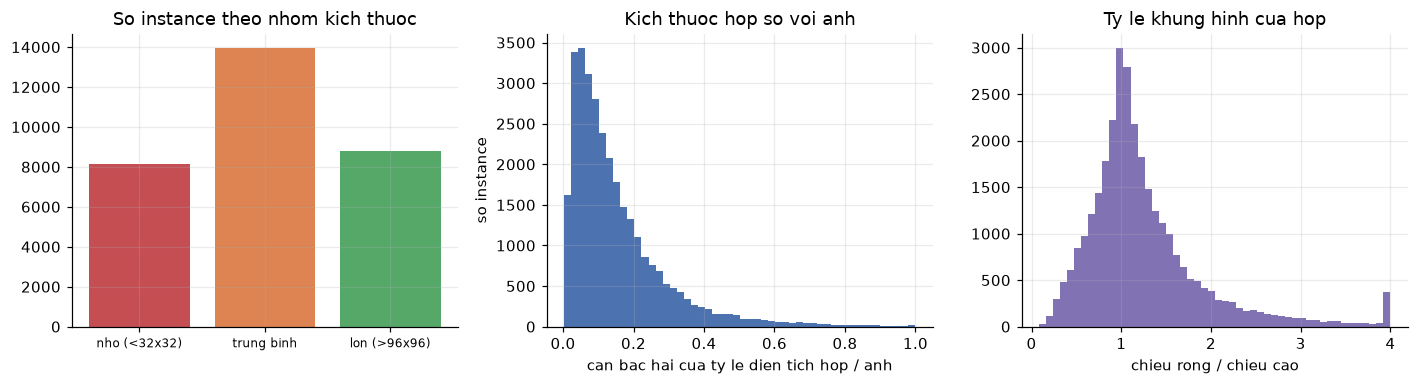

Kich thuoc anh: rong trung vi 640px, cao trung vi 480px


In [5]:
areas, rel_areas, ratios = [], [], []
img_w, img_h = [], []
for r in records["train"].records:
    img_w.append(r["width"])
    img_h.append(r["height"])
    for a in r["annotations"]:
        w, h = a["bbox"][2], a["bbox"][3]
        if w <= 0 or h <= 0:
            continue
        areas.append(w * h)
        rel_areas.append((w * h) / (r["width"] * r["height"]))
        ratios.append(w / h)

areas = np.array(areas)
buckets = pd.Series({
    "nho (<32x32)": int((areas < 32 ** 2).sum()),
    "trung binh": int(((areas >= 32 ** 2) & (areas < 96 ** 2)).sum()),
    "lon (>96x96)": int((areas >= 96 ** 2).sum()),
})
print("Ty le theo nhom kich thuoc COCO (tap train):")
print((100 * buckets / buckets.sum()).round(1).to_string(), "\n")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

axes[0].bar(buckets.index, buckets.values, color=["#c44e52", "#dd8452", "#55a868"])
axes[0].set_title("So instance theo nhom kich thuoc")
axes[0].tick_params(axis="x", labelsize=8)

axes[1].hist(np.sqrt(rel_areas), bins=50, color="#4c72b0")
axes[1].set_xlabel("can bac hai cua ty le dien tich hop / anh")
axes[1].set_ylabel("so instance")
axes[1].set_title("Kich thuoc hop so voi anh")

axes[2].hist(np.clip(ratios, 0, 4), bins=50, color="#8172b3")
axes[2].set_xlabel("chieu rong / chieu cao")
axes[2].set_title("Ty le khung hinh cua hop")

fig.tight_layout()
plt.show()

print(f"Kich thuoc anh: rong trung vi {int(np.median(img_w))}px, "
      f"cao trung vi {int(np.median(img_h))}px")

Tỉ lệ nhóm nhỏ càng cao thì bài toán càng khó, vì vật thể nhỏ mất nhiều thông tinsau khi ảnh được thu nhỏ về kích thước đầu vào của mô hình.

## 5. Các lớp xuất hiện cùng nhauBảng dưới đếm số ảnh mà hai lớp cùng xuất hiện. Đường chéo là số ảnh chỉ chứa lớp đó.

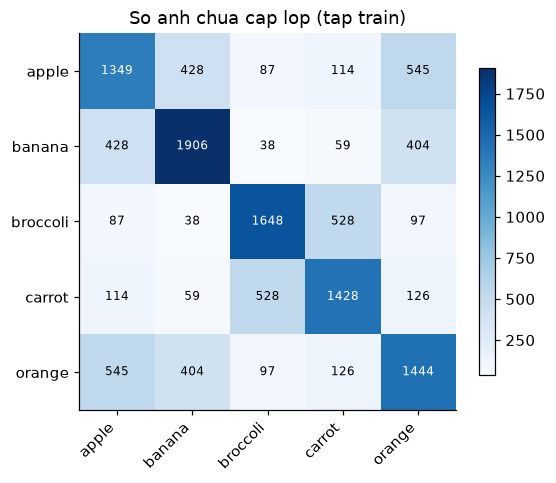

In [6]:
n = len(CLASSES)
matrix = np.zeros((n, n), dtype=int)
idx = {c: i for i, c in enumerate(CLASSES)}

for r in records["train"].records:
    present = sorted({COCO_ID_TO_CLASS[a["category_id"]] for a in r["annotations"]})
    for i, a in enumerate(present):
        matrix[idx[a], idx[a]] += 1
        for b in present[i + 1:]:
            matrix[idx[a], idx[b]] += 1
            matrix[idx[b], idx[a]] += 1

fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(matrix, cmap="Blues")
ax.set_xticks(range(n), CLASSES, rotation=45, ha="right")
ax.set_yticks(range(n), CLASSES)
ax.grid(False)
for i in range(n):
    for j in range(n):
        ax.text(j, i, matrix[i, j], ha="center", va="center", fontsize=8,
                color="white" if matrix[i, j] > matrix.max() * 0.6 else "black")
ax.set_title("So anh chua cap lop (tap train)")
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
plt.show()

## 6. Vị trí của vật thể trong ảnhTâm của mỗi hộp được quy về toạ độ tương đối trong khoảng 0 den 1, rồi đếm theo lưới.Nếu vật thể tập trung ở giữa ảnh thì mô hình dễ học hơn so với khi chúng rải đều.

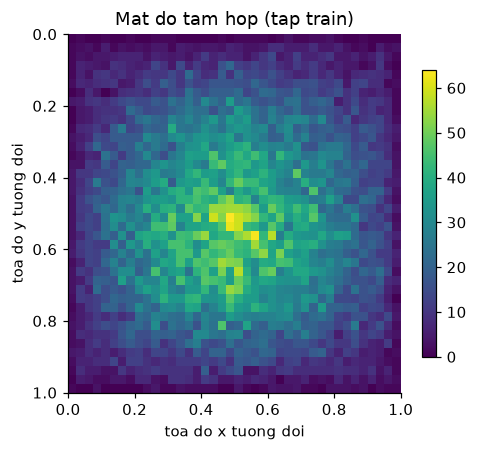

In [7]:
cx, cy = [], []
for r in records["train"].records:
    for a in r["annotations"]:
        x, y, w, h = a["bbox"]
        cx.append((x + w / 2) / r["width"])
        cy.append((y + h / 2) / r["height"])

fig, ax = plt.subplots(figsize=(4.6, 4.2))
h = ax.hist2d(cx, cy, bins=40, range=[[0, 1], [0, 1]], cmap="viridis")
ax.invert_yaxis()
ax.set_xlabel("toa do x tuong doi")
ax.set_ylabel("toa do y tuong doi")
ax.set_title("Mat do tam hop (tap train)")
ax.grid(False)
fig.colorbar(h[3], ax=ax, shrink=0.8)
fig.tight_layout()
plt.show()

## 7. Ba mô hình gốc chạy trên cùng ba ảnhBa mô hình dưới đây đều ở trạng thái gốc: chúng là checkpoint huấn luyện trêntoàn bộ COCO, chưa được huấn luyện lại trên bộ dữ liệu này. Cả 5 lớp đang xétđều nằm trong 80 lớp của COCO nên các mô hình phát hiện được ngay.Với YOLO, đầu ra 80 lớp được lọc lại còn 5 lớp cần thiết.Ngưỡng hiển thị là 0.35, giống ngưỡng dự kiến dùng cho ứng dụng web.Ba ảnh được chọn theo tiêu chí cố định: có từ 2 đến 15 vật thể và kích thướcvật thể ở mức thông thường. Nếu chọn theo số lượng hộp thì hay rơi vào nhữngảnh có vật thể rất nhỏ, ở đó cả ba mô hình đều không trả về gì nên không sosánh được.

In [8]:
import torch
from src.config import CLASS_TO_COCO_ID, DISPLAY_SCORE_THRESHOLD
from src.evaluation.runner import load_pretrained

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
THRESHOLD = DISPLAY_SCORE_THRESHOLD
test = records["test"]

# Chon anh co vat the kich thuoc thong thuong, giong anh nguoi dung se tai len.
# Neu chi chon theo so luong hop thi hay roi vao nhung anh vat the rat nho,
# ma o do ca ba mo hinh deu khong tra ve gi nen hinh ve khong so sanh duoc.
def median_rel_area(i):
    r = test.records[i]
    areas = [(a["bbox"][2] * a["bbox"][3]) / (r["width"] * r["height"])
             for a in r["annotations"]]
    return float(np.median(areas)) if areas else 0.0


candidates = sorted(
    (i for i in range(len(test))
     if 2 <= len(test.records[i]["annotations"]) <= 15 and median_rel_area(i) > 0.02),
    key=lambda i: len(test.records[i]["annotations"]),
)
picks = [candidates[int(p * len(candidates))] for p in (0.25, 0.55, 0.85)]
images = [test.image(i) for i in picks]
paths = [str(test.path(i)) for i in picks]
sizes = [(test.records[i]["height"], test.records[i]["width"]) for i in picks]
print("Anh duoc chon:", [test.records[i]["file_name"] for i in picks])

Anh duoc chon: ['000000537506.jpg', '000000350388.jpg', '000000335427.jpg']


In [9]:
def to_records(boxes_xyxy, scores, class_ids):
    """Doi ve dang chung: bbox kieu xywh, category_id 1..5, kem score."""
    out = []
    for (x0, y0, x1, y1), s, c in zip(boxes_xyxy, scores, class_ids):
        if s < THRESHOLD:
            continue
        out.append({"bbox": [float(x0), float(y0), float(x1 - x0), float(y1 - y0)],
                    "category_id": int(c), "score": float(s)})
    return out


detections = {}

# --- SSDLite (torchvision): tra ve hop theo pixel goc, nhan da la 1..5 ---
from torchvision.transforms.functional import to_tensor

loaded, _ = load_pretrained("ssdlite", "auto")
with torch.no_grad():
    outs = loaded.model([to_tensor(im).to(device) for im in images])
detections["SSDLite320"] = [
    to_records(o["boxes"].cpu().tolist(), o["scores"].cpu().tolist(), o["labels"].cpu().tolist())
    for o in outs
]
del loaded, outs
torch.cuda.empty_cache()
print("SSDLite xong")

SSDLite xong


In [10]:
# --- YOLO11s (ultralytics): dau ra 80 lop, loc con 5 lop roi doi chi so ---
loaded, class_map = load_pretrained("yolo11s", "auto")
results_yolo = loaded.model.predict(paths, imgsz=640, conf=THRESHOLD,
                                    classes=sorted(class_map), verbose=False,
                                    device=0 if device.type == "cuda" else "cpu")
detections["YOLO11s"] = [
    to_records(r.boxes.xyxy.cpu().tolist(), r.boxes.conf.cpu().tolist(),
               [class_map[int(c)] for c in r.boxes.cls.cpu().tolist()])
    for r in results_yolo
]
del loaded, results_yolo
torch.cuda.empty_cache()
print("YOLO11s xong")

YOLO11s xong


In [11]:
# --- D-FINE-N (transformers): can target_sizes de doi hop ve pixel goc ---
loaded, _ = load_pretrained("dfine", "auto")
encoding = loaded.processor(images=[np.asarray(im) for im in images], return_tensors="pt")
with torch.no_grad():
    out = loaded.model(pixel_values=encoding["pixel_values"].to(device))
processed = loaded.processor.post_process_object_detection(
    out, threshold=THRESHOLD, target_sizes=torch.tensor(sizes, device=device)
)
detections["D-FINE-N"] = [
    to_records(p["boxes"].cpu().tolist(), p["scores"].cpu().tolist(),
               [int(c) + 1 for c in p["labels"].cpu().tolist()])
    for p in processed
]
del loaded, out, processed
torch.cuda.empty_cache()
print("D-FINE-N xong")

C:\Users\KUONG\miniconda3\envs\objdet\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[transformers] You passed `num_labels=5` which is incompatible to the `id2label` map of length `80`.


Loading weights:   0%|          | 0/644 [00:00<?, ?it/s]

Loading weights:  79%|███████▊  | 507/644 [00:00<00:00, 5036.25it/s]

Loading weights: 100%|██████████| 644/644 [00:00<00:00, 5006.39it/s]

...

Loading weights:   0%|          | 0/644 [00:00<?, ?it/s]

Loading weights:  69%|██████▊   | 442/644 [00:00<00:00, 4418.35it/s]

Loading weights: 100%|██████████| 644/644 [00:00<00:00, 4382.54it/s]

C:\Users\KUONG\miniconda3\envs\objdet\Lib\site-packages\transformers\image_processing_backends.py:135: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  image = torch.from_numpy(image).contiguous()


D-FINE-N xong


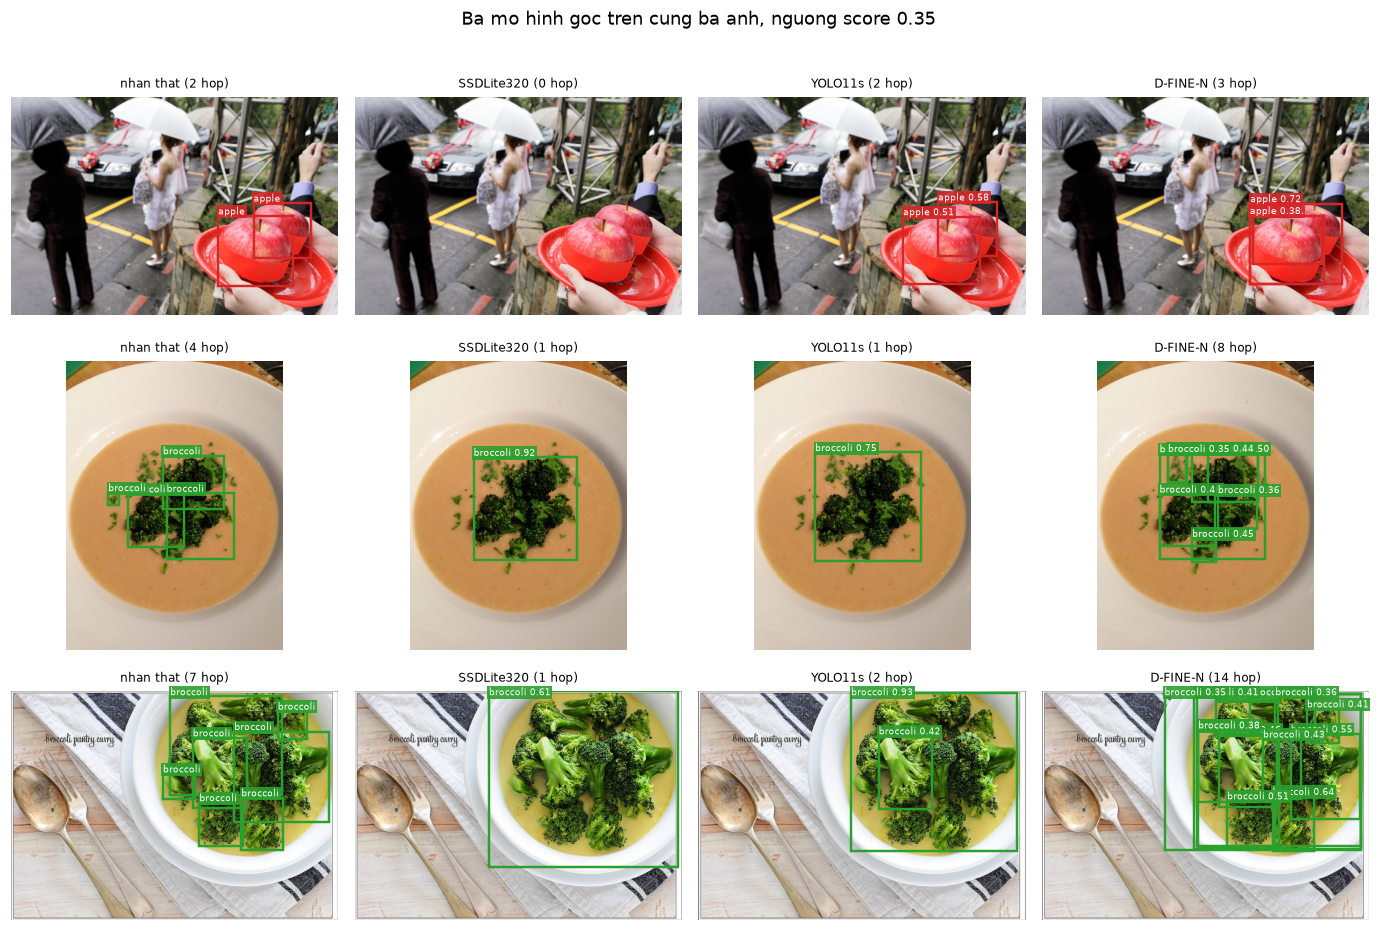

In [12]:
names = list(detections)
fig, axes = plt.subplots(len(picks), 1 + len(names),
                         figsize=(3.2 * (1 + len(names)), 2.9 * len(picks)))
axes = np.atleast_2d(axes)

for row, idx_img in enumerate(picks):
    truth = [{"bbox": a["bbox"], "category_id": a["category_id"]}
             for a in test.records[idx_img]["annotations"]]
    draw_boxes(axes[row][0], images[row], truth, f"nhan that ({len(truth)} hop)")
    for col, name in enumerate(names, start=1):
        found = detections[name][row]
        draw_boxes(axes[row][col], images[row], found, f"{name} ({len(found)} hop)")

fig.suptitle(f"Ba mo hinh goc tren cung ba anh, nguong score {THRESHOLD}", y=0.999)
fig.tight_layout()
plt.show()

In [13]:
summary = pd.DataFrame({
    "nhan that": [len(test.records[i]["annotations"]) for i in picks],
    **{name: [len(detections[name][r]) for r in range(len(picks))] for name in names},
}, index=[test.records[i]["file_name"] for i in picks])
summary.index.name = "anh"
summary

,nhan that,SSDLite320,YOLO11s,D-FINE-N
anh,,,,
000000537506.jpg,2,0,2,3
000000350388.jpg,4,1,1,8
000000335427.jpg,7,1,2,14


Bảng trên đếm số hộp vượt ngưỡng 0.35. Số hộp ít hơn nhãn thật là chuyện thường gặpở những ảnh có nhiều vật thể nhỏ nằm sát nhau, vì mô hình hay gộp một cụm thành một hộp.## Tóm tắtNhững điểm rút ra từ phần trên:- Bộ dữ liệu có 7.137 ảnh và 38.460 instance, chia thành ba tập không giao nhau.- Số lượng instance giữa 5 lớp không đều nhau, cần lưu ý khi đọc kết quả theo từng lớp.- Phần lớn ảnh chứa vài vật thể, nhưng có những ảnh chứa hàng chục vật thể nhỏ.- Tỉ lệ vật thể nhỏ theo chuẩn COCO là yếu tố ảnh hưởng nhiều tới mAP.- Ba mô hình gốc đều phát hiện được 5 lớp này mà không cần huấn luyện lại.